# TP2 PARTE 1

Análisis descriptivo de las variables del dataset

A continuación se describen las principales variables del dataset meteorológico australiano (`weatherAUS.csv`):

- **Date**: Fecha de la observación meteorológica. Permite analizar tendencias temporales y estacionalidad.
- **Location**: Nombre de la localidad donde se tomaron los datos. Es una variable categórica que identifica el punto geográfico.
- **MinTemp**: Temperatura mínima registrada ese día (°C). Variable numérica, su rango depende de la zona y época del año.
- **MaxTemp**: Temperatura máxima registrada ese día (°C). Variable numérica, útil para analizar extremos térmicos.
- **Rainfall**: Precipitación acumulada (mm). Variable numérica, suele tener muchos ceros (días sin lluvia).
- **Evaporation**: Agua evaporada (mm). Variable numérica, relacionada con temperatura y humedad.
- **Sunshine**: Horas de sol. Variable numérica, indica la cantidad de radiación solar recibida.
- **WindGustDir**: Dirección del viento en la ráfaga más fuerte. Variable categórica (N, NE, E, etc.).
- **WindGustSpeed**: Velocidad de la ráfaga más fuerte (km/h). Variable numérica, muestra eventos extremos de viento.
- **WindDir9am / WindDir3pm**: Dirección del viento a las 9am y 3pm. Variables categóricas.
- **WindSpeed9am / WindSpeed3pm**: Velocidad del viento a las 9am y 3pm (km/h). Variables numéricas.
- **Humidity9am / Humidity3pm**: Humedad relativa (%) a las 9am y 3pm. Variables numéricas, rango 0-100.
- **Pressure9am / Pressure3pm**: Presión atmosférica (hPa) a las 9am y 3pm. Variables numéricas, rango típico 1000-1030 hPa.
- **Cloud9am / Cloud3pm**: Cobertura de nubes (octas) a las 9am y 3pm. Variables numéricas, rango 0-8.
- **Temp9am / Temp3pm**: Temperatura a las 9am y 3pm (°C). Variables numéricas.
- **RainToday**: Indica si llovió ese día (Yes/No). Variable categórica binaria.
- **RainTomorrow**: Variable objetivo, indica si lloverá al día siguiente (Yes/No).


##Consigna 1: Creación de Clusters

Teniendo en cuenta las 8 regiones que componen el país decidimos asignar las siguientes:
* New  South Wales
* Victoria
* Queensland
* Western Australia
* South Australia
* Tasmania
* Australian Capital Territory
* Northen Territory

In [ ]:
"""
Se solicita en primera instancia crear clusters con las ciudades del Dataset para catalogarlas
en otra categoría nueva: regiones. La cantidad de regiones será definida por cada grupo, observarlas
en un gráfico de latitud y longitud para acompañar la decisión.
"""

'\nSe solicita en primera instancia crear clusters con las ciudades del Dataset para catalogarlas\nen otra categoría nueva: regiones. La cantidad de regiones será definida por cada grupo, observarlas\nen un gráfico de latitud y longitud para acompañar la decisión.\n'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import warnings


In [ ]:
# Comenzamos por leer el archivo con datos meteorológicos
df = pd.read_csv('weatherAUS.csv')
df.head(3)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No


In [ ]:
# Atributos del DataFrame
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

In [ ]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [ ]:
# Verificamos los máximos y mínimos de las variables numéricas
minimos = df.min(numeric_only=True)
maximos = df.max(numeric_only=True)

tabla = pd.DataFrame({
    'Variable': minimos.index,
    'Mínimo': minimos.values,
    'Máximo': maximos.values
})

print(tabla)

         Variable  Mínimo  Máximo
0         MinTemp    -8.5    33.9
1         MaxTemp    -4.8    48.1
2        Rainfall     0.0   371.0
3     Evaporation     0.0   145.0
4        Sunshine     0.0    14.5
5   WindGustSpeed     6.0   135.0
6    WindSpeed9am     0.0   130.0
7    WindSpeed3pm     0.0    87.0
8     Humidity9am     0.0   100.0
9     Humidity3pm     0.0   100.0
10    Pressure9am   980.5  1041.0
11    Pressure3pm   977.1  1039.6
12       Cloud9am     0.0     9.0
13       Cloud3pm     0.0     9.0
14        Temp9am    -7.2    40.2
15        Temp3pm    -5.4    46.7


In [ ]:
# Listado de localidades del data set original weatherAUS.csv
print('El listado de', df['Location'].nunique(), 'localidades del dataset original es:')
locs = sorted(df['Location'].unique())
for i in range(0, len(locs), 6):
    print(', '.join(locs[i:i+6]))

El listado de 49 localidades del dataset original es:
Adelaide, Albany, Albury, AliceSprings, BadgerysCreek, Ballarat
Bendigo, Brisbane, Cairns, Canberra, Cobar, CoffsHarbour
Dartmoor, Darwin, GoldCoast, Hobart, Katherine, Launceston
Melbourne, MelbourneAirport, Mildura, Moree, MountGambier, MountGinini
Newcastle, Nhil, NorahHead, NorfolkIsland, Nuriootpa, PearceRAAF
Penrith, Perth, PerthAirport, Portland, Richmond, Sale
SalmonGums, Sydney, SydneyAirport, Townsville, Tuggeranong, Uluru
WaggaWagga, Walpole, Watsonia, Williamtown, Witchcliffe, Wollongong
Woomera


Se encontró un archivo con las ciudades australianas y sus coordenadas en https://simplemaps.com/data/au-cities pero presentaba muchas diferencias de nombres con las localidades del data set weatherAUS.csv con lo cual se lo descartó como referencia de latitud y longitud.
Posteriormente se consultaron a chatGPT cuales eran las latitudes y longitudes que correspondían a las 49 localidades que comprenden weatherAUS.csv incluyendo la fuente de información de donde se extrajo el dato. Este data set se denomina "localidades_australia_nuevo.csv" y es el que usamos finalmente para el trabajo.

In [ ]:
# Este es el listado de localidades que hemos decidido agrupar en regiones
df_localidades = pd.read_csv('localidades_australia_nuevo.csv')
df_localidades.head(3)

,Localidad,Latitud,Longitud,Fuente
0,Adelaide,-34.928500,138.600700,Wikipedia/Geonames
1,Albany,-35.022778,117.881386,Wikipedia/Geonames
2,Albury,-36.080600,146.915600,Wikipedia/Geonames


In [ ]:
# Hacemos un merge entre df y df_cities usando Location y Localidad como claves
df_full = pd.merge(df, df_localidades, left_on='Location', right_on='Localidad')
df_full.head(3)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Localidad,Latitud,Longitud,Fuente
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,8.0,NaN,16.9,21.8,No,No,Albury,-36.0806,146.9156,Wikipedia/Geonames
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,NaN,NaN,17.2,24.3,No,No,Albury,-36.0806,146.9156,Wikipedia/Geonames
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,NaN,2.0,21.0,23.2,No,No,Albury,-36.0806,146.9156,Wikipedia/Geonames


In [ ]:
# Para asegurarnos de no hacer clustering usando atributos incompletos, vamos a comprobar
# si existen filas con latitud o longitud nulas en df_full
nulas = df_full[df_full['Latitud'].isnull() | df_full['Longitud'].isnull()]
print("Filas con latitud o longitud nula:", len(nulas))

Filas con latitud o longitud nula: 0


In [ ]:
from sklearn.cluster import KMeans
# Columnas con coordenadas
X = df_full[['Latitud', 'Longitud']]

# KMeans con 8 clusters (uno para cada región)
kmeans = KMeans(n_clusters=8, random_state=42)
df_full['Cluster'] = kmeans.fit_predict(X)

# Nombres oficiales de las regiones de Australia
nombres_regiones = [
    'New South Wales',
    'Victoria',
    'Queensland',
    'Western Australia',
    'South Australia',
    'Tasmania',
    'Australian Capital Territory',
    'Northern Territory'
]

# Obtener los centroides de cada cluster
centroides = kmeans.cluster_centers_

# Crear un diccionario para asignar nombres basado en la latitud (sur → norte)
# Ordenamos los centroides de menor a mayor latitud
orden_centroides = np.argsort(centroides[:,0])[::-1]  # de norte a sur
cluster_a_nombre = {orden_centroides[i]: nombres_regiones[i] for i in range(len(nombres_regiones))}

# Mapear los clusters a nombres reales
df_full['Region'] = df_full['Cluster'].map(cluster_a_nombre)

df_full = df_full.drop(columns=['Cluster'])

In [ ]:
df_full['Region'].unique()

array(['Australian Capital Territory', 'South Australia',
       'Western Australia', 'Northern Territory', 'Victoria', 'Tasmania',
       'Queensland', 'New South Wales'], dtype=object)

In [ ]:
!pip install simplekml

In [ ]:
# Este bloque es para generar la presnetación geográfica de las localidades agrupadas por regiones en Google Earth

import simplekml

# Definir colores para cada región (formato aabbggrr)
colores = {
    'Australian Capital Territory': 'ff0000ff',    # Rojo
    'South Australia': 'ff00ff00',   # Verde
    'Western Australia' : 'ffff0000',      # Azul
    'Northern Territory': 'ff00ffff',       # Amarillo
    'Victoria': 'ffff00ff',        # Magenta
    'Tasmania': 'ffffff00',   # Cyan
    'Queensland': 'ff888888',   # Gris
    'New South Wales': 'ff000000',     # Negro
}

# Agrupar por localidad de interés
localidades_interes = df_full['Localidad'].unique()[:49]  # Selecciona las primeras 49 localidades únicas
df_localidades_kml = df_full[df_full['Localidad'].isin(localidades_interes)].groupby('Localidad').first().reset_index()

# Crear un nuevo objeto KML
kml = simplekml.Kml()

# Crear un folder por región
folders = {region: kml.newfolder(name=region) for region in colores.keys()}

# Recorrer el DataFrame agrupado y agregar cada localidad
for idx, row in df_localidades_kml.iterrows():
    region = row['Region']
    nombre = row['Localidad']
    lat = row['Latitud']
    lon = row['Longitud']
    if pd.notnull(lat) and pd.notnull(lon):
        pnt = folders[region].newpoint(name=nombre, coords=[(lon, lat)])
        pnt.style.iconstyle.color = colores[region]
        pnt.style.iconstyle.scale = 1

# Guardar el archivo KML
kml.save("localidades_agrupadas_regiones.kml")

##Consigna 2: Análisis descriptivo

A tener en cuenta
Posibles redundancias

Temp9am, Temp3pm, MaxTemp y MinTemp están correlacionadas entre sí.

Igual con Humidity9am y Humidity3pm.

Los modelos de ML suelen elegir una u otra automáticamente

### 1. Análisis y decisión sobre datos faltantes

In [ ]:
### 1. Análisis y decisión sobre datos faltantes
print('Valores faltantes por columnas')
print(df.isna().sum())

Valores faltantes por columnas
Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64


In [ ]:
# Veamos el porcentaje de faltantes por Region para los peores casos
variables = ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm', 'RainTomorrow', 'RainToday']
faltantes_por_region = df_full.groupby('Region')[variables].apply(lambda x: (x.isnull().sum() / len(x) * 100).round(2))
print(faltantes_por_region)


                              Evaporation  Sunshine  Cloud9am  Cloud3pm  \
Region                                                                    
Australian Capital Territory        55.88     65.49     52.00     51.78   
New South Wales                      3.08     33.16      0.88     15.24   
Northern Territory                  25.89     30.70     29.98     33.85   
Queensland                          38.83     45.43     33.87     32.96   
South Australia                     56.83     62.22     38.68     41.36   
Tasmania                            57.92     44.91     47.50     51.08   
Victoria                             7.58     14.79      6.27      8.34   
Western Australia                    7.78     14.59      2.19      2.03   

                              RainTomorrow  RainToday  
Region                                                 
Australian Capital Territory          1.26       1.26  
New South Wales                       0.42       0.38  
Northern Territory       

La variable objetivo RainTomorrow tiene un porcentaje de faltantes máximo de 4,31% en el peor caso (Región S.A.). Podemos considerar su eliminación del df_full

### 2. Visualización de datos

In [ ]:
n_columns=['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustSpeed','WindSpeed9am',
        'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm']

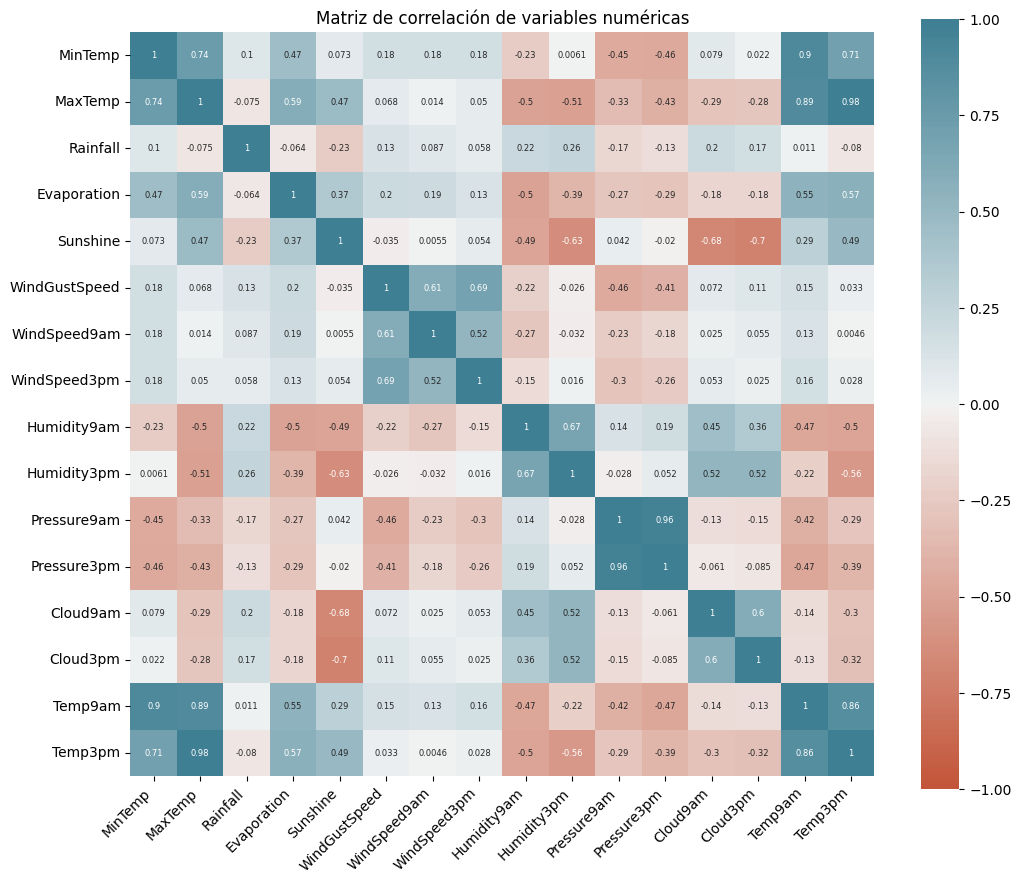

In [ ]:

corr = df[n_columns].corr(method='pearson')
plt.figure(figsize=(12,10))
plt.title('Matriz de correlación de variables numéricas')
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 6}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.show()

In [ ]:
corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ['Variable1', 'Variable2', 'Correlation']

# Quitar duplicados y la diagonal (correlación consigo misma = 1)
corr_pairs = corr_pairs[corr_pairs['Variable1'] != corr_pairs['Variable2']]
corr_pairs = corr_pairs.drop_duplicates(subset=['Correlation'])

# Ordenar por el valor absoluto de la correlación (de mayor a menor)
corr_pairs = corr_pairs.reindex(corr_pairs['Correlation'].abs().sort_values(ascending=False).index)

print('Top 30 variables con mayor correlación')
print(corr_pairs.head(30))

Top 30 variables con mayor correlación
         Variable1     Variable2  Correlation
31         MaxTemp       Temp3pm     0.984503
171    Pressure9am   Pressure3pm     0.961326
14         MinTemp       Temp9am     0.901821
30         MaxTemp       Temp9am     0.887210
239        Temp9am       Temp3pm     0.860591
1          MinTemp       MaxTemp     0.736555
15         MinTemp       Temp3pm     0.708906
77        Sunshine      Cloud3pm    -0.703930
87   WindGustSpeed  WindSpeed3pm     0.686307
76        Sunshine      Cloud9am    -0.675323
137    Humidity9am   Humidity3pm     0.666949
73        Sunshine   Humidity3pm    -0.629130
86   WindGustSpeed  WindSpeed9am     0.605303
205       Cloud9am      Cloud3pm     0.603564
19         MaxTemp   Evaporation     0.587932
63     Evaporation       Temp3pm     0.572893
159    Humidity3pm       Temp3pm    -0.557841
62     Evaporation       Temp9am     0.545115
157    Humidity3pm      Cloud3pm     0.523120
103   WindSpeed9am  WindSpeed3pm     0.51

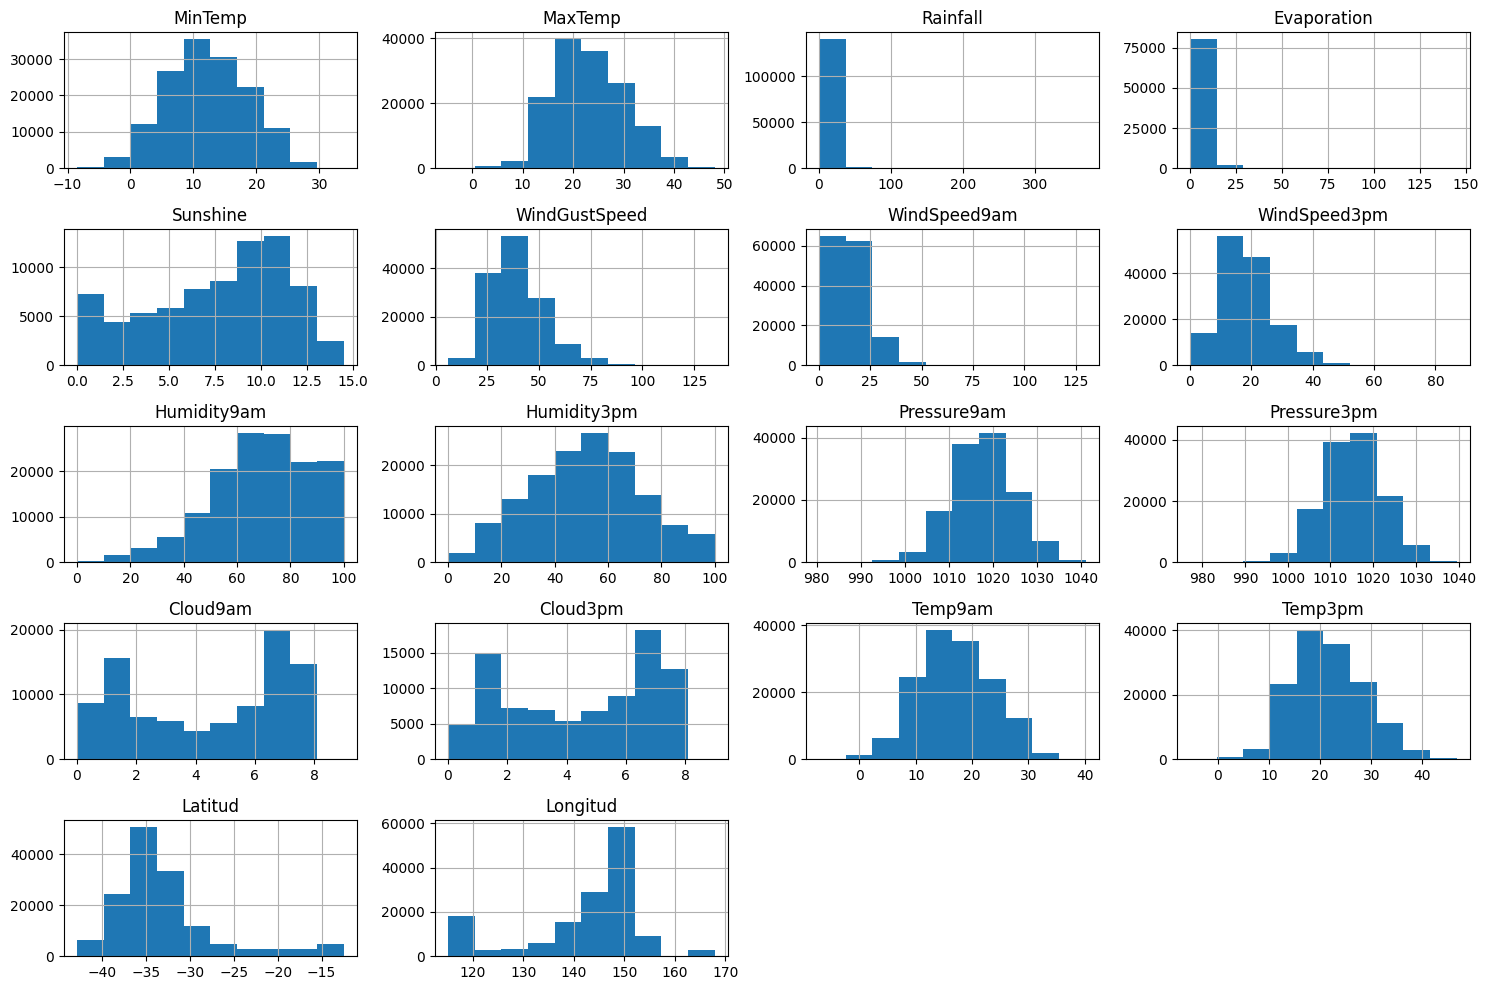

In [ ]:
# **Histogramas:**

df_full.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

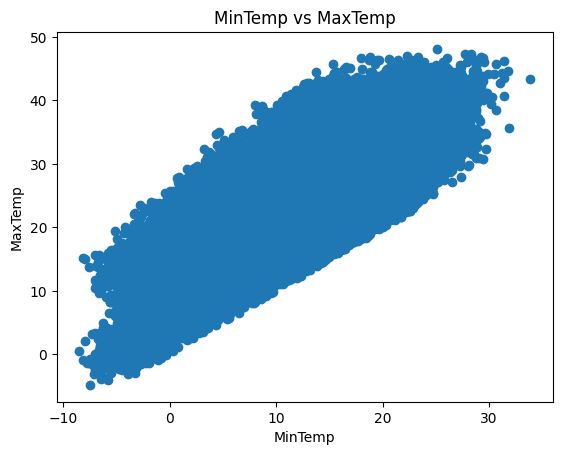

In [ ]:
# **Scatterplot entre dos variables:**

plt.scatter(df_full['MinTemp'], df_full['MaxTemp'])
plt.xlabel('MinTemp')
plt.ylabel('MaxTemp')
plt.title('MinTemp vs MaxTemp')
plt.show()

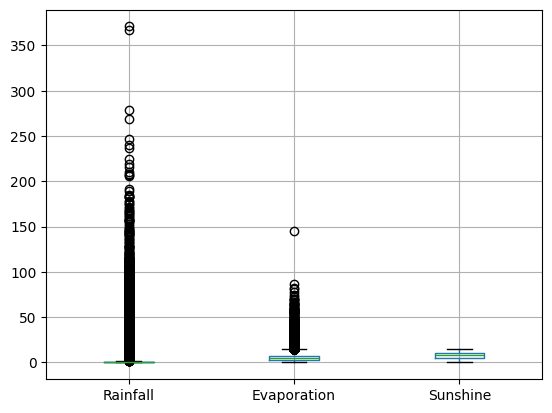

In [ ]:
# Diagramas de caja:

df_full[['Rainfall', 'Evaporation', 'Sunshine']].boxplot()
plt.show()

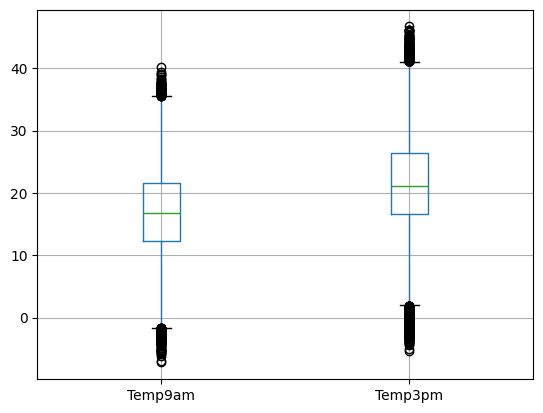

In [ ]:
df_full[['Temp9am', 'Temp3pm']].boxplot()
plt.show()

In [ ]:
# 3. ¿Está balanceado el dataset? ¿Por qué hacemos esta pregunta?
df_full['RainTomorrow'] = df_full['RainTomorrow'].astype('category')
counts=df_full["RainTomorrow"].value_counts()
print(counts)

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64


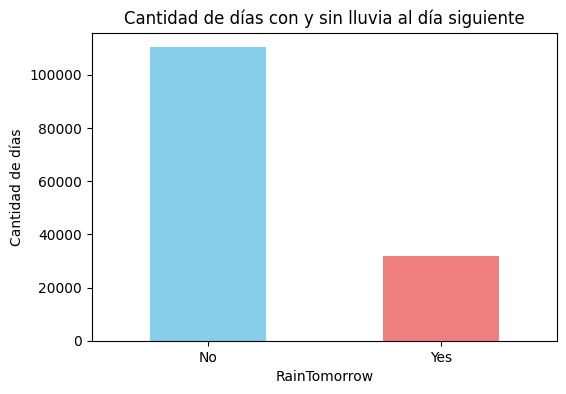

In [ ]:
# La variable objetivo está muy desbalanceada, con muchos más casos de "No" que de "Yes". Esto puede afectar el rendimiento
# de los modelos de clasificación, ya que pueden tender a predecir la clase mayoritaria.

plt.figure(figsize=(6,4))
counts.plot(kind='bar', color=['skyblue', 'lightcoral'])

plt.title("Cantidad de días con y sin lluvia al día siguiente")
plt.xlabel("RainTomorrow")
plt.ylabel("Cantidad de días")
plt.xticks(rotation=0)
plt.show()

Como podemos observar en el gráfico, nuestro dataset presenta un fuerte desbalance en la variable target.
Este aspecto es fundamental de visualizar, ya que, si dicho desbalance persiste al momento de entrenar el modelo, es muy probable que este tienda a predecir con mayor frecuencia la clase mayoritaria (en este caso, “No va a llover”).
Esto ocurre porque el modelo puede alcanzar una aparente alta precisión simplemente prediciendo siempre la clase dominante, pero a costa de un bajo desempeño en la detección de los días en que sí llueve, que justamente suelen ser los más relevantes en un problema de predicción meteorológica.

###Imputación de valores faltantes + ingeniería de variables

In [ ]:
df_full[df_full['RainTomorrow'].isna()]

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Localidad,Latitud,Longitud,Fuente,Region
14,2008-12-15,Albury,8.4,24.6,0.0,NaN,NaN,NaN,NaN,S,...,NaN,15.9,23.5,No,NaN,Albury,-36.0806,146.9156,Wikipedia/Geonames,Australian Capital Territory
283,2009-09-10,Albury,2.6,NaN,0.0,NaN,NaN,NaN,NaN,E,...,6.0,9.7,14.3,No,NaN,Albury,-36.0806,146.9156,Wikipedia/Geonames,Australian Capital Territory
435,2010-02-09,Albury,22.1,35.1,0.0,NaN,NaN,NaN,NaN,ENE,...,1.0,26.9,33.5,No,NaN,Albury,-36.0806,146.9156,Wikipedia/Geonames,Australian Capital Territory
437,2010-02-11,Albury,21.5,35.0,0.0,NaN,NaN,NaN,NaN,SSE,...,8.0,24.2,33.1,No,NaN,Albury,-36.0806,146.9156,Wikipedia/Geonames,Australian Capital Territory
443,2010-02-17,Albury,15.5,30.6,0.0,NaN,NaN,NaN,NaN,SE,...,NaN,19.4,30.0,No,NaN,Albury,-36.0806,146.9156,Wikipedia/Geonames,Australian Capital Territory
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144955,2016-02-07,Uluru,22.5,37.7,0.0,NaN,NaN,SE,50.0,SE,...,NaN,28.8,37.2,No,NaN,Uluru,-25.3415,131.0354,Wikipedia/Geonames,Queensland
145091,2016-06-22,Uluru,12.3,19.1,0.0,NaN,NaN,NaN,NaN,NaN,...,8.0,15.6,18.9,No,NaN,Uluru,-25.3415,131.0354,Wikipedia/Geonames,Queensland
145092,2016-06-23,Uluru,14.2,18.7,NaN,NaN,NaN,NaN,NaN,W,...,8.0,16.6,17.5,NaN,NaN,Uluru,-25.3415,131.0354,Wikipedia/Geonames,Queensland
145335,2017-02-21,Uluru,13.5,NaN,0.0,NaN,NaN,NaN,NaN,ENE,...,NaN,25.2,34.4,No,NaN,Uluru,-25.3415,131.0354,Wikipedia/Geonames,Queensland


In [ ]:
# Mostrar cantidad de filas con RainTomorrow nulo en df_full
print("Filas con RainTomorrow nulo:", df_full['RainTomorrow'].isna().sum())

Filas con RainTomorrow nulo: 3267


In [ ]:
# Tamaño inicial
n_inicial = len(df_full)

df_full = df_full.dropna(subset=['RainTomorrow'])

n_final = len(df_full)

# Calcular porcentaje de pérdida
porcentaje_perdido = (n_inicial - n_final) / n_inicial * 100

print(f"Se eliminaron {n_inicial - n_final} filas.")
print(f"Esto representa un {porcentaje_perdido:.2f}% del dataset.")


Se eliminaron 3267 filas.
Esto representa un 2.25% del dataset.


In [ ]:
import numpy as np

# Diccionario de direcciones a grados
direccion_a_grados = {
    'N': 0,
    'NNE': 22.5,
    'NE': 45,
    'ENE': 67.5,
    'E': 90,
    'ESE': 112.5,
    'SE': 135,
    'SSE': 157.5,
    'S': 180,
    'SSW': 202.5,
    'SW': 225,
    'WSW': 247.5,
    'W': 270,
    'WNW': 292.5,
    'NW': 315,
    'NNW': 337.5
}

# Mapear a grados
df_full['WindGustDir_deg'] = df_full['WindGustDir'].map(direccion_a_grados)
df_full['WindDir9am_deg'] = df_full['WindDir9am'].map(direccion_a_grados)
df_full['WindDir3pm_deg'] = df_full['WindDir3pm'].map(direccion_a_grados)

# Convertir a radianes
df_full['wind_gust_rad'] = np.deg2rad(df_full['WindGustDir_deg'])
df_full['wind_9am_rad'] = np.deg2rad(df_full['WindDir9am_deg'])
df_full['wind_3pm_rad'] = np.deg2rad(df_full['WindDir3pm_deg'])

# Codificación cíclica
df_full['wind_gust_x'] = np.cos(df_full['wind_gust_rad'])
df_full['wind_gust_y'] = np.sin(df_full['wind_gust_rad'])

df_full['wind_9am_x'] = np.cos(df_full['wind_9am_rad'])
df_full['wind_9am_y'] = np.sin(df_full['wind_9am_rad'])

df_full['wind_3pm_x'] = np.cos(df_full['wind_3pm_rad'])
df_full['wind_3pm_y'] = np.sin(df_full['wind_3pm_rad'])

# Limpiar columnas intermedias
df_full.drop([
    'WindGustDir_deg', 'WindDir9am_deg', 'WindDir3pm_deg',
    'wind_gust_rad', 'wind_9am_rad', 'wind_3pm_rad'
], axis=1, inplace=True)



### 4. Codificación de variables categóricas

In [ ]:
# Conviertimos variables categóricas a numéricas para usar para predicciónes:
categorical_cols = ['RainToday','Region']

# Generar las dummies
df_encoded = pd.get_dummies(df_full, columns=categorical_cols, drop_first=True)

# Identificar las columnas que salieron de esas categorías
dummy_cols = [col for col in df_encoded.columns if any(cat in col for cat in categorical_cols)]

# Convertir solo esas a int
df_encoded[dummy_cols] = df_encoded[dummy_cols].astype(int)

df_encoded.head(3)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,wind_3pm_x,wind_3pm_y,RainToday_Yes,Region_New South Wales,Region_Northern Territory,Region_Queensland,Region_South Australia,Region_Tasmania,Region_Victoria,Region_Western Australia
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,0.382683,-0.92388,0,0,0,0,0,0,0,0
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,-0.382683,-0.92388,0,0,0,0,0,0,0,0
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,-0.382683,-0.92388,0,0,0,0,0,0,0,0


### 5. Validación cruzada train-test

In [ ]:
from sklearn.model_selection import train_test_split

# Columnas a excluir
columnas_excluir = [
    'Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
    'Localidad', 'Latitud', 'Longitud', 'Fuente'
]

# Definir X e y
X = df_full.drop(columns=columnas_excluir + ['RainTomorrow'])  # reemplazá 'target' por el nombre real
y = df_full['RainTomorrow']

# División en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Agregamos stratify=y para que en el conjunto de test y de train hayan los mismos porcentajes de No lluvia y Si lluvia, lo hacemos ya que nuestro dataset esta desbalanceado

In [ ]:
y_train = y_train.map({'Yes': 1, 'No': 0}).astype(int)
y_test = y_test.map({'Yes': 1, 'No': 0}).astype(int)

In [ ]:
X_train.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Cloud9am,Cloud3pm,Temp9am,Temp3pm,wind_gust_x,wind_gust_y,wind_9am_x,wind_9am_y,wind_3pm_x,wind_3pm_y
count,113241.000000,113496.000000,112623.000000,65059.000000,59410.000000,106314.000000,112672.000000,111624.000000,112336.000000,110857.000000,...,70877.000000,68085.000000,113019.000000,111551.000000,1.062690e+05,106269.000000,1.056990e+05,1.056990e+05,1.106880e+05,110688.000000
mean,12.172898,23.218870,2.360774,5.484554,7.622614,39.953684,13.981885,18.637255,68.838493,51.505227,...,4.434146,4.502445,16.977363,21.676257,-4.593029e-02,-0.016909,1.195289e-02,1.887015e-02,-4.544502e-02,-0.018659
std,6.406406,7.120048,8.544243,4.208367,3.783751,13.571751,8.865721,8.798030,19.053148,20.806658,...,2.887667,2.722294,6.499264,6.942100,6.998372e-01,0.712630,7.192344e-01,6.944151e-01,7.006920e-01,0.711777
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-7.200000,-5.400000,-1.000000e+00,-1.000000,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,...,1.000000,2.000000,12.300000,16.600000,-7.071068e-01,-0.707107,-7.071068e-01,-7.071068e-01,-7.071068e-01,-0.707107
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,...,5.000000,5.000000,16.700000,21.100000,-1.836970e-16,0.000000,6.123234e-17,1.224647e-16,-1.836970e-16,0.000000
75%,16.800000,28.200000,0.600000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,...,7.000000,7.000000,21.600000,26.400000,7.071068e-01,0.707107,7.071068e-01,7.071068e-01,7.071068e-01,0.707107
max,31.400000,48.100000,371.000000,145.000000,14.300000,135.000000,130.000000,87.000000,100.000000,100.000000,...,9.000000,9.000000,40.200000,46.200000,1.000000e+00,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113754 entries, 103642 to 122308
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   MinTemp        113241 non-null  float64
 1   MaxTemp        113496 non-null  float64
 2   Rainfall       112623 non-null  float64
 3   Evaporation    65059 non-null   float64
 4   Sunshine       59410 non-null   float64
 5   WindGustSpeed  106314 non-null  float64
 6   WindSpeed9am   112672 non-null  float64
 7   WindSpeed3pm   111624 non-null  float64
 8   Humidity9am    112336 non-null  float64
 9   Humidity3pm    110857 non-null  float64
 10  Pressure9am    102467 non-null  float64
 11  Pressure3pm    102492 non-null  float64
 12  Cloud9am       70877 non-null   float64
 13  Cloud3pm       68085 non-null   float64
 14  Temp9am        113019 non-null  float64
 15  Temp3pm        111551 non-null  float64
 16  RainToday      112623 non-null  object 
 17  Region         113754 non-nul

In [ ]:
X_test.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Cloud9am,Cloud3pm,Temp9am,Temp3pm,wind_gust_x,wind_gust_y,wind_9am_x,wind_9am_y,wind_3pm_x,wind_3pm_y
count,28315.000000,28375.000000,28164.000000,16291.000000,14967.000000,26609.00000,28173.000000,27939.000000,28083.000000,27726.000000,...,17659.000000,17014.000000,28270.000000,27916.000000,2.659400e+04,26594.000000,2.648100e+04,26481.000000,2.772700e+04,27727.000000
mean,12.240399,23.258439,2.306789,5.411000,7.633741,40.10658,14.082384,18.638856,68.865079,51.392159,...,4.449403,4.506054,17.028069,21.731100,-5.646229e-02,-0.024901,1.234540e-02,0.018178,-5.159624e-02,-0.016861
std,6.390604,7.107928,8.141317,4.107989,3.772788,13.65628,9.002646,8.824706,19.044195,20.762332,...,2.884451,2.714050,6.467040,6.919508,7.005634e-01,0.710943,7.195450e-01,0.694125,7.001265e-01,0.711978
min,-8.200000,-2.500000,0.000000,0.000000,0.000000,7.00000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,-5.200000,-3.800000,-1.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000e+00,-1.000000
25%,7.700000,18.000000,0.000000,2.600000,4.900000,31.00000,7.000000,13.000000,57.000000,36.000000,...,1.000000,2.000000,12.300000,16.700000,-7.071068e-01,-0.707107,-7.071068e-01,-0.707107,-7.071068e-01,-0.707107
50%,12.100000,22.600000,0.000000,4.600000,8.500000,39.00000,13.000000,19.000000,70.000000,52.000000,...,5.000000,5.000000,16.800000,21.100000,-1.836970e-16,0.000000,6.123234e-17,0.000000,-1.836970e-16,0.000000
75%,16.900000,28.300000,0.800000,7.200000,10.700000,48.00000,19.000000,24.000000,83.000000,65.000000,...,7.000000,7.000000,21.575000,26.500000,7.071068e-01,0.707107,7.071068e-01,0.707107,7.071068e-01,0.707107
max,33.900000,47.300000,236.800000,64.800000,14.500000,130.00000,87.000000,83.000000,100.000000,100.000000,...,8.000000,8.000000,39.000000,46.700000,1.000000e+00,1.000000,1.000000e+00,1.000000,1.000000e+00,1.000000


In [ ]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28439 entries, 48872 to 91578
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MinTemp        28315 non-null  float64
 1   MaxTemp        28375 non-null  float64
 2   Rainfall       28164 non-null  float64
 3   Evaporation    16291 non-null  float64
 4   Sunshine       14967 non-null  float64
 5   WindGustSpeed  26609 non-null  float64
 6   WindSpeed9am   28173 non-null  float64
 7   WindSpeed3pm   27939 non-null  float64
 8   Humidity9am    28083 non-null  float64
 9   Humidity3pm    27726 non-null  float64
 10  Pressure9am    25712 non-null  float64
 11  Pressure3pm    25720 non-null  float64
 12  Cloud9am       17659 non-null  float64
 13  Cloud3pm       17014 non-null  float64
 14  Temp9am        28270 non-null  float64
 15  Temp3pm        27916 non-null  float64
 16  RainToday      28164 non-null  object 
 17  Region         28439 non-null  object 
 18  wind_gu

###Imputación de faltantes

In [ ]:
# Lista de columnas a analizar
columns_to_check = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
    'Sunshine', 'WindGustSpeed', 'WindSpeed9am',
    'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
    'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
    'Temp9am', 'Temp3pm', 'wind_gust_x', 'wind_gust_y',
    'wind_9am_x', 'wind_9am_y', 'wind_3pm_x', 'wind_3pm_y'
]

In [ ]:
# Función para escalar preservando NaN
def safe_scale_features(df, features, scaler):
    """Escala características preservando valores NaN"""
    df_scaled = df.copy()
    # Identify rows where at least one feature to be scaled is not NaN
    mask_notna_any = df[features].notna().any(axis=1)

    if mask_notna_any.sum() > 0:  # Only scale if there are rows with data
        # Select the subset of data to scale (only specified features and non-NaN rows)
        data_to_scale = df.loc[mask_notna_any, features]

        # Apply the scaler
        scaled_data = scaler.transform(data_to_scale)

        # Assign the scaled data back to the original DataFrame, preserving NaN positions
        # This is done by creating a temporary DataFrame for the scaled data
        # and then using update or direct assignment based on the index
        df_scaled.loc[mask_notna_any, features] = scaled_data

    return df_scaled

In [ ]:
# ===============
# ESCALADO MINMAX
# ===============
from sklearn.preprocessing import MinMaxScaler
minmax_scaler = MinMaxScaler()

# Ajustar el escalador SOLO con datos limpios de entrenamiento (sin NaN)
# Usamos las mismas features definidas para Isolation Forest
train_clean_for_minmax_scaling = X_train[columns_to_check].dropna()
print(f"Datos usados para ajustar escalador MinMax: {len(train_clean_for_minmax_scaling)} registros")

minmax_scaler.fit(train_clean_for_minmax_scaling)

# Crear copias para escalado MinMax
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Aplicar escalado MinMax preservando NaN
print("Aplicando escalado MinMax a datos de entrenamiento...")
X_train_scaled = safe_scale_features(X_train_scaled, columns_to_check, minmax_scaler)

print("Aplicando escalado MinMax a datos de prueba...")
X_test_scaled = safe_scale_features(X_test_scaled, columns_to_check, minmax_scaler)

Datos usados para ajustar escalador MinMax: 45121 registros
Aplicando escalado MinMax a datos de entrenamiento...
Aplicando escalado MinMax a datos de prueba...


In [ ]:
# ==================================
# DETECCIÓN DE OUTLIERS ESTADÍSTICOS
# ==================================
from tqdm import tqdm
from sklearn.ensemble import IsolationForest
print("\n=== ETAPA 2: DETECCIÓN DE OUTLIERS ESTADÍSTICOS ===")

def detect_statistical_outliers(df, features, method='iqr'):
    """
    Detecta outliers usando método IQR o Isolation Forest
    """
    df_no_outliers = df.copy()

    if method == 'iqr':
        # Método IQR (Rango Intercuartílico)
        for feature in features:
            if df_no_outliers[feature].notna().sum() > 0:  # Solo si hay datos no nulos
                Q1 = df_no_outliers[feature].quantile(0.25)
                Q3 = df_no_outliers[feature].quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 3 * IQR  # Usar 3*IQR para ser menos agresivo
                upper_bound = Q3 + 3 * IQR

                # Marcar outliers como NaN para posterior imputación
                outlier_mask = (
                    (df_no_outliers[feature] < lower_bound) |
                    (df_no_outliers[feature] > upper_bound)
                )

                # Convertir outliers a NaN en lugar de eliminar filas
                df_no_outliers.loc[outlier_mask, feature] = np.nan

    elif method == 'isolation_forest':
        # Método Isolation Forest (solo para datos completos)
        complete_data = df_no_outliers[features].dropna()
        if len(complete_data) > 100:  # Necesitamos suficientes datos
            iso_forest = IsolationForest(contamination=0.01, random_state=42)
            outlier_labels = iso_forest.fit_predict(complete_data)

            # Marcar outliers detectados como NaN
            outlier_indices = complete_data.index[outlier_labels == -1]
            print("Se encontraron",len(outlier_indices), "valores atìpicos.")
            for feature in tqdm(features):
                df_no_outliers.loc[outlier_indices, feature] = np.nan


    return df_no_outliers


=== ETAPA 2: DETECCIÓN DE OUTLIERS ESTADÍSTICOS ===


In [ ]:
# ============================================================
# COMBINACIÓN DE MÉTODOS: IQR PARA ALGUNAS VARIABLES, ISOLATION FOREST PARA EL RESTO
# ============================================================

# Variables que usarán método IQR
iqr_features = ['MaxTemp', 'MinTemp', 'Temp9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp3pm']

# El resto de variables (excluyendo las de IQR) usarán Isolation Forest
iso_features = [c for c in columns_to_check if c not in iqr_features]

X_train_no_outliers = detect_statistical_outliers(X_train_scaled, iqr_features, method='iqr')
X_train_no_outliers = detect_statistical_outliers(X_train_no_outliers, iso_features, method='isolation_forest')

X_test_no_outliers = detect_statistical_outliers(X_test_scaled, iqr_features, method='iqr')
X_test_no_outliers = detect_statistical_outliers(X_test_no_outliers, iso_features, method='isolation_forest')

print("\n✅ Detección de outliers completada.")


Se encontraron 453 valores atìpicos.


100%|██████████| 15/15 [00:00<00:00, 428.19it/s]


Se encontraron 114 valores atìpicos.


100%|██████████| 15/15 [00:00<00:00, 917.16it/s]


✅ Detección de outliers completada.


Para la detección de outliers se consideraron dos grupos de variables según la forma de sus distribuciones.
En primer lugar, para aquellas variables con una distribución aproximadamente normal o “campanular” y con bajo nivel de sesgo, se aplicó el método del IQR (Interquartile Range), dado que resulta un procedimiento computacionalmente más eficiente y suficientemente preciso en este tipo de casos.

Por otro lado, para las variables con distribuciones sesgadas o que, de forma visual, evidencian una alta presencia de valores atípicos, se optó por un método más robusto y sofisticado: Isolation Forest, que, si bien requiere un mayor tiempo de cómputo, ofrece un mejor desempeño en la detección de outliers en este tipo de distribuciones.

In [ ]:

# Función para calcular los porcentajes de valores faltantes
def calculate_missing_percentage(df, columns, denominator_len):
    """
    Calcula el porcentaje de valores faltantes para una lista de columnas.
    """
    missing_data_list = []
    for col in columns:
        if col in df.columns:
            # La fórmula original del usuario utiliza len(X_train) como denominador
            missing_percentage = (df[col].isna().sum() * 100 / denominator_len).round(2)
            missing_data_list.append({'Columna': col, 'Porcentaje_Faltante': missing_percentage})
        else:
            missing_data_list.append({'Columna': col, 'Porcentaje_Faltante': 'Columna no encontrada'})

    return pd.DataFrame(missing_data_list)

missing_train_df = calculate_missing_percentage(X_train_no_outliers, columns_to_check, len(X_train))

missing_test_df = calculate_missing_percentage(X_test_no_outliers, columns_to_check, len(X_train))

print("Porcentaje de valores faltantes en X_train:")
print(missing_train_df)
print("\n" + "="*50 + "\n")
print("Porcentaje de valores faltantes en X_test:")
print(missing_test_df)

Porcentaje de valores faltantes en X_train:
          Columna  Porcentaje_Faltante
0         MinTemp                 0.45
1         MaxTemp                 0.23
2        Rainfall                 1.39
3     Evaporation                43.21
4        Sunshine                48.17
5   WindGustSpeed                 6.94
6    WindSpeed9am                 1.35
7    WindSpeed3pm                 2.27
8     Humidity9am                 1.64
9     Humidity3pm                 2.55
10    Pressure9am                 9.93
11    Pressure3pm                 9.91
12       Cloud9am                38.09
13       Cloud3pm                40.55
14        Temp9am                 0.65
15        Temp3pm                 1.94
16    wind_gust_x                 6.98
17    wind_gust_y                 6.98
18     wind_9am_x                 7.48
19     wind_9am_y                 7.48
20     wind_3pm_x                 3.09
21     wind_3pm_y                 3.09


Porcentaje de valores faltantes en X_test:
          Colu

Datos faltantes menor o igual al 1% (cantidad de faltantes baja): imputación por la mediana

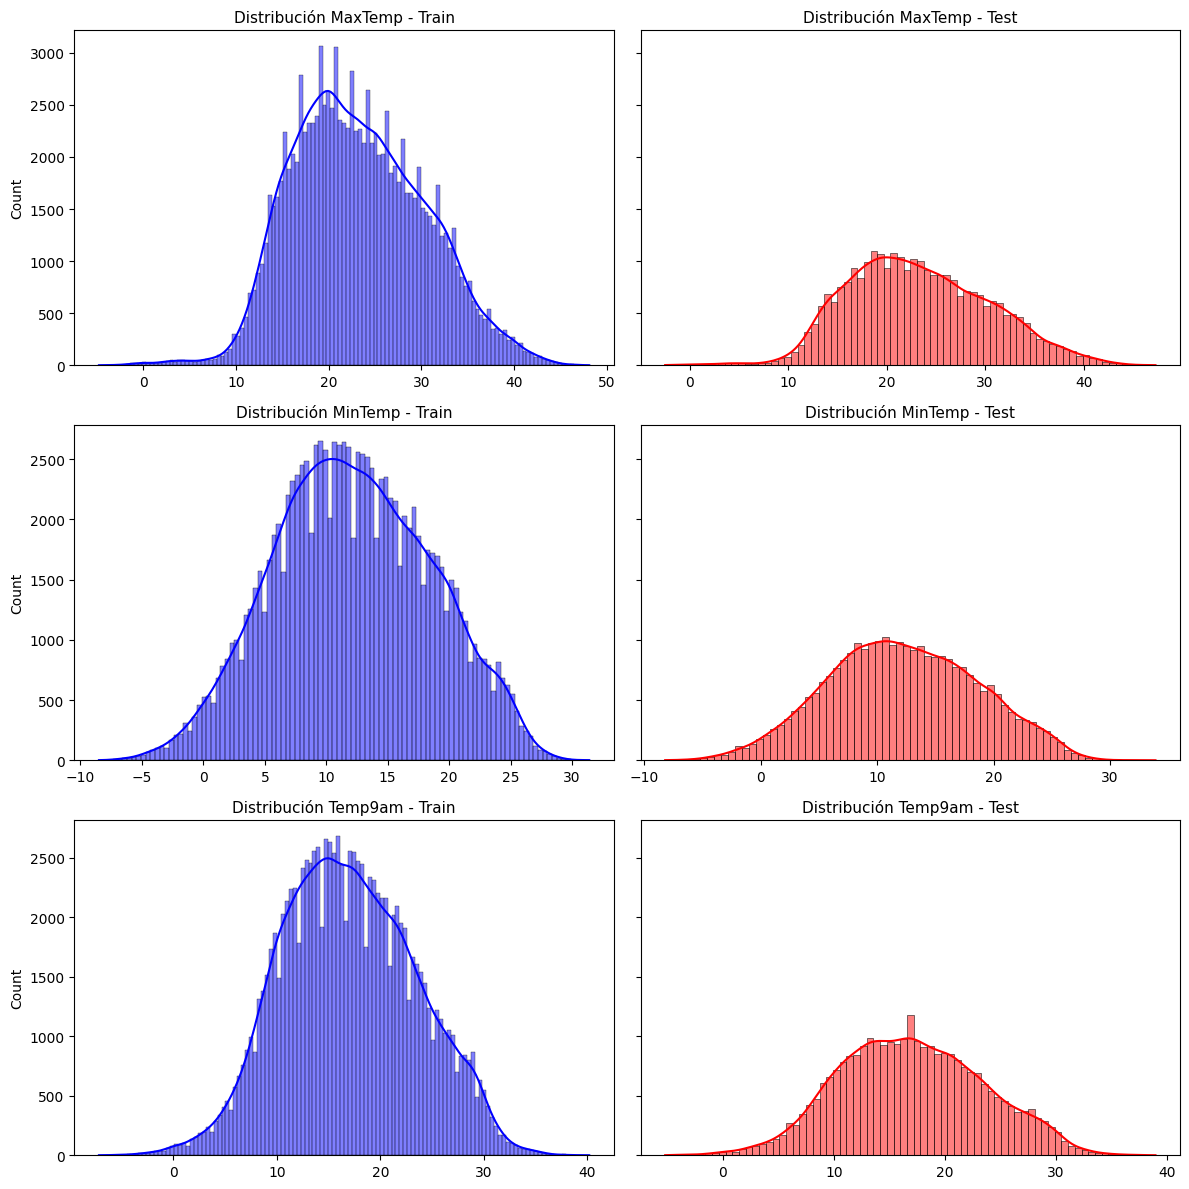

In [ ]:
variables_menos_1per = ['MaxTemp', 'MinTemp','Temp9am']

# Crear subplots: una fila por variable, dos columnas (Train / Test)
fig, axes = plt.subplots(len(variables_menos_1per), 2, figsize=(12, 4 * len(variables_menos_1per)), sharey='row')

for i, var in enumerate(variables_menos_1per):
    # Gráfico Train
    sns.histplot(X_train[var], kde=True, color="blue", ax=axes[i, 0])
    axes[i, 0].set_title(f"Distribución {var} - Train", fontsize=11)
    axes[i, 0].set_xlabel("")

    # Gráfico Test
    sns.histplot(X_test[var], kde=True, color="red", ax=axes[i, 1])
    axes[i, 1].set_title(f"Distribución {var} - Test", fontsize=11)
    axes[i, 1].set_xlabel("")


plt.tight_layout()
plt.show()

In [ ]:
def impute_based_on_train_percentages(df_train, df_test, df_train_percentages):
    """
    Identifica y imputa valores faltantes en X_train y X_test.
    La decisión de imputar y el valor de la mediana se basan
    únicamente en los datos de entrenamiento (X_train).

    Args:
        df_train (pd.DataFrame): El DataFrame de entrenamiento.
        df_test (pd.DataFrame): El DataFrame de pruebas.
        df_train_percentages (pd.DataFrame): El DataFrame con los porcentajes
                                            de nulos de X_train.

    Returns:
        tuple: Una tupla con los DataFrames de entrenamiento y pruebas imputados.
    """
    df_train_imputed = df_train.copy()
    df_test_imputed = df_test.copy()
    imputed_columns = []

    # 1. Identifica las columnas a imputar basándose ÚNICAMENTE en los porcentajes de X_train
    cols_to_impute = df_train_percentages[df_train_percentages['Porcentaje_Faltante'] <= 1.0]['Columna'].tolist()

    print(f"Columnas a imputar (basadas en X_train <= 1%): {cols_to_impute}")

    for col in cols_to_impute:
        if col in df_train_imputed.columns and col in df_test_imputed.columns:
            # 2. Calcula la mediana con los datos de X_train
            median_value = df_train_imputed[col].median()

            # 3. Imputa los valores nulos en X_train y X_test usando esa misma mediana
            df_train_imputed[col] = df_train_imputed[col].fillna(median_value)
            df_test_imputed[col] = df_test_imputed[col].fillna(median_value)

            imputed_columns.append(col)
            print(f"  - '{col}': imputada en ambos conjuntos con la mediana de X_train ({median_value:.4f})")
        else:
            print(f"  - '{col}': No encontrada en ambos DataFrames. Omitida.")

    return df_train_imputed, df_test_imputed

# Ejecutar la imputación
X_train, X_test = impute_based_on_train_percentages(X_train_no_outliers, X_test_no_outliers, missing_train_df)

Columnas a imputar (basadas en X_train <= 1%): ['MinTemp', 'MaxTemp', 'Temp9am']
  - 'MinTemp': imputada en ambos conjuntos con la mediana de X_train (0.4908)
  - 'MaxTemp': imputada en ambos conjuntos con la mediana de X_train (0.4205)
  - 'Temp9am': imputada en ambos conjuntos con la mediana de X_train (0.4339)


Datos faltantes entre 1% y 10% (cantidad de faltantes moderado a alto): imputación por KNN


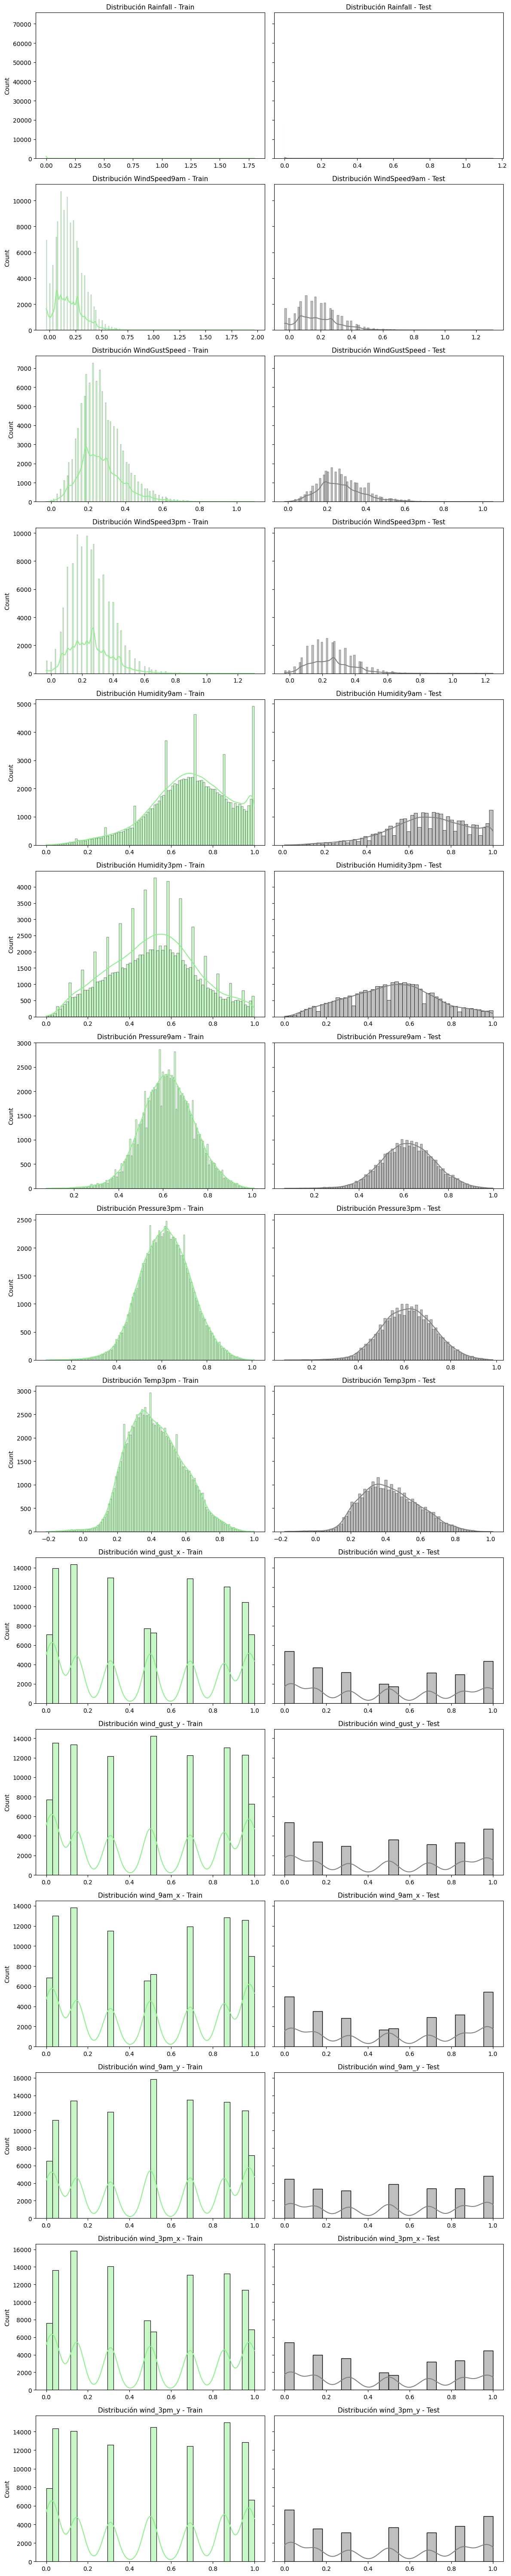

In [ ]:
variables = [
    'Rainfall',  'WindSpeed9am','WindGustSpeed', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
    'Pressure9am', 'Pressure3pm', 'Temp3pm',
    'wind_gust_x', 'wind_gust_y', 'wind_9am_x', 'wind_9am_y', 'wind_3pm_x', 'wind_3pm_y'
]

# Crear subplots: una fila por variable, dos columnas (Train / Test)
fig, axes = plt.subplots(len(variables), 2, figsize=(12, 4 * len(variables)), sharey='row')

for i, var in enumerate(variables):
    # Gráfico Train
    sns.histplot(X_train[var], kde=True, color="lightgreen", ax=axes[i, 0])
    axes[i, 0].set_title(f"Distribución {var} - Train", fontsize=11)
    axes[i, 0].set_xlabel("")

    # Gráfico Test
    sns.histplot(X_test[var], kde=True, color="gray", ax=axes[i, 1])
    axes[i, 1].set_title(f"Distribución {var} - Test", fontsize=11)
    axes[i, 1].set_xlabel("")

# Ajuste de layout
plt.tight_layout()
plt.show()


In [ ]:
# =============================================================================
# IMPUTACIÓN KNN CON VALIDACIÓN
# =============================================================================
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=10, weights='distance')

print("Ajustando imputador KNN...")
knn_imputer.fit(X_train[variables])

X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()

print("Aplicando imputación a conjunto de entrenamiento...")
X_train_imputed[variables] = knn_imputer.transform(
    X_train[variables]
)

print("Aplicando imputación a conjunto de prueba...")
X_test_imputed[variables] = knn_imputer.transform(
    X_test[variables]
)

Ajustando imputador KNN...
Aplicando imputación a conjunto de entrenamiento...
Aplicando imputación a conjunto de prueba...


In [ ]:
# Ver cuántos nulos hay por columna de interés
X_train_imputed[variables_menos_1per].isnull().sum()

,0
MaxTemp,0
MinTemp,0
Temp9am,0


In [ ]:
X_train_imputed[variables].isnull().sum()

,0
Rainfall,0
WindSpeed9am,0
WindGustSpeed,0
WindSpeed3pm,0
Humidity9am,0
Humidity3pm,0
Pressure9am,0
Pressure3pm,0
Temp3pm,0
wind_gust_x,0


Datos faltantes mayor al 10% (cantidad de faltantes muy alta): imputación con RandomForestRegressor

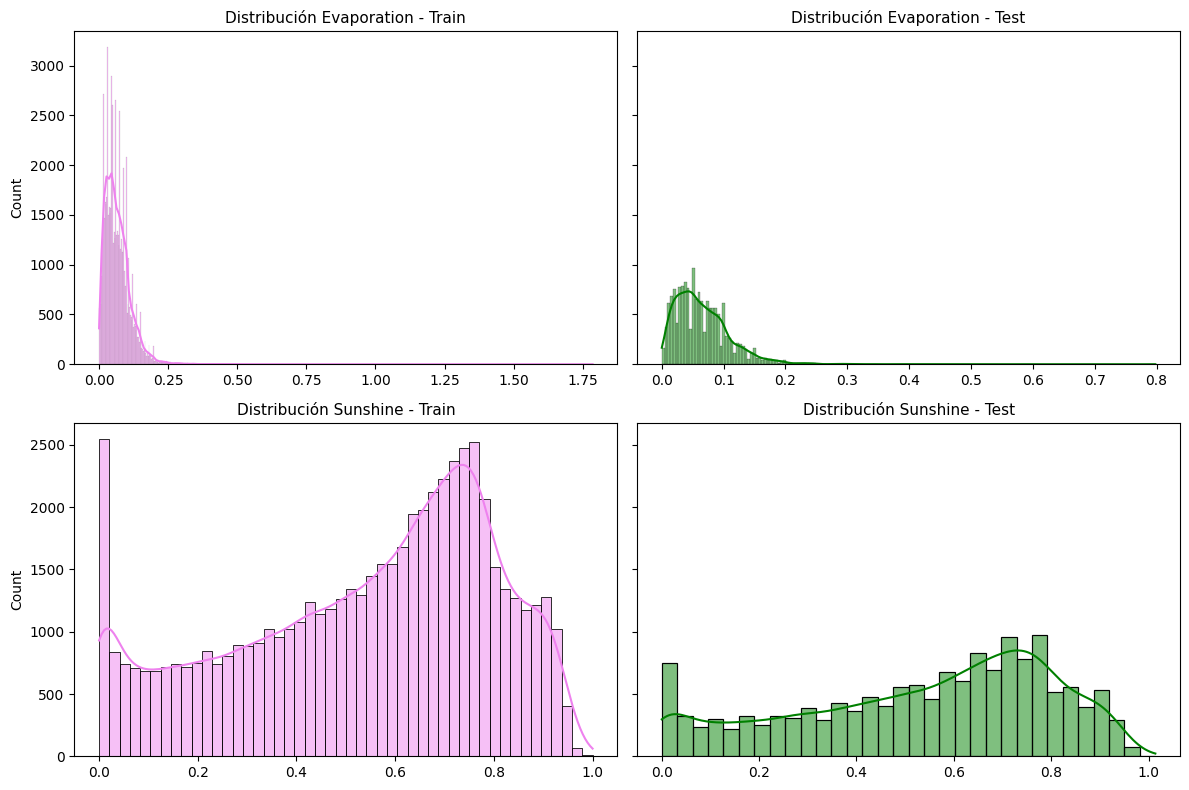

In [ ]:
# Lista de variables que querés graficar
variables_mas_10per = ['Evaporation', 'Sunshine']

# Crear subplots: una fila por variable, dos columnas (Train / Test)
fig, axes = plt.subplots(len(variables_mas_10per), 2, figsize=(12, 4 * len(variables_mas_10per)), sharey='row')

for i, var in enumerate(variables_mas_10per):
    # Gráfico Train
    sns.histplot(X_train_imputed[var], kde=True, color="violet", ax=axes[i, 0])
    axes[i, 0].set_title(f"Distribución {var} - Train", fontsize=11)
    axes[i, 0].set_xlabel("")

    # Gráfico Test
    sns.histplot(X_test_imputed[var], kde=True, color="green", ax=axes[i, 1])
    axes[i, 1].set_title(f"Distribución {var} - Test", fontsize=11)
    axes[i, 1].set_xlabel("")

# Ajuste de layout
plt.tight_layout()
plt.show()

In [ ]:
X_train_prueba=X_train_imputed.copy()
X_test_prueba=X_test_imputed.copy()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Definimos las columnas a excluir del entrenamiento
cols_to_exclude = ['Sunshine', 'Evaporation']

# Creamos la lista de características para entrenar el modelo.
# Excluimos las variables que no son predictoras o que tienen datos faltantes.
features = [c for c in columns_to_check if c in X_train_prueba.columns and c not in cols_to_exclude]

# Separamos los datos de entrenamiento por filas con y sin valores nulos en 'Sunshine'
train_sun = X_train_prueba[X_train_prueba['Sunshine'].notnull()]
test_sun_train = X_train_prueba[X_train_prueba['Sunshine'].isnull()]

#Entrnamiento
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(train_sun[features], train_sun['Sunshine'])

y_pred = rf.predict(train_sun[features])
print('R²:', r2_score(train_sun['Sunshine'], y_pred))
print('MAE:', mean_absolute_error(train_sun['Sunshine'], y_pred))



R²: 0.9655863534945079
MAE: 0.03595680910503577


In [ ]:
# Imputamos los valores nulos de Sunshine en el conjunto de entrenamiento (X_train_prueba) y (X_test_prueba) usando el modelo entrenado
X_train_prueba.loc[X_train_prueba['Sunshine'].isnull(), 'Sunshine'] = rf.predict(test_sun_train[features])
test_sun_test = X_test_prueba[X_test_prueba['Sunshine'].isnull()]
X_test_prueba.loc[X_test_prueba['Sunshine'].isnull(), 'Sunshine'] = rf.predict(test_sun_test[features])

In [ ]:
cols_to_exclude = [ 'Evaporation']

features = [c for c in columns_to_check if c in X_train_prueba.columns and c not in cols_to_exclude]

# Separamos los datos de entrenamiento por filas con y sin valores nulos en 'Evaporation'
train_sun = X_train_prueba[X_train_prueba['Evaporation'].notnull()]
test_sun_train = X_train_prueba[X_train_prueba['Evaporation'].isnull()]

#Entrenamiento
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(train_sun[features], train_sun['Evaporation'])

y_pred = rf.predict(train_sun[features])
print('R²:', r2_score(train_sun['Evaporation'], y_pred))
print('MAE:', mean_absolute_error(train_sun['Evaporation'], y_pred))



R²: 0.9307400673699568
MAE: 0.007548974961376342


In [ ]:
#Imputamos los valores nulos de Evaporation en el conjunto de entrenamiento (X_train_prueba) y (X_test_prueba) usando el modelo entrenado
X_train_prueba.loc[X_train_prueba['Evaporation'].isnull(), 'Evaporation'] = rf.predict(test_sun_train[features])

test_sun_test = X_test_prueba[X_test_prueba['Evaporation'].isnull()]
X_test_prueba.loc[X_test_prueba['Evaporation'].isnull(), 'Evaporation'] = rf.predict(test_sun_test[features])

In [ ]:
X_train_prueba.columns

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RainToday', 'Region', 'wind_gust_x',
       'wind_gust_y', 'wind_9am_x', 'wind_9am_y', 'wind_3pm_x', 'wind_3pm_y'],
      dtype='object')

Imputación de variable categóricas:
* RainToday imputado con moda ya que posee pocos valores faltantes.
* Cloud9am y Cloud3pm:imputación con RandomForestRegressor ya que contiene muchos nulos y son cualitativas ordinales por lo que debemos imputar a partir de valores reales.

In [ ]:
"""
mode_train = X_train_prueba['RainToday'].mode()[0]
X_train_prueba.loc[X_train_prueba['RainToday'].isnull(), 'RainToday'] = mode_train
X_test_prueba.loc[X_test_prueba['RainToday'].isnull(), 'RainToday'] = mode_train
"""

"\nmode_train = X_train_prueba['RainToday'].mode()[0]\nX_train_prueba.loc[X_train_prueba['RainToday'].isnull(), 'RainToday'] = mode_train\nX_test_prueba.loc[X_test_prueba['RainToday'].isnull(), 'RainToday'] = mode_train\n"

In [ ]:
# Imputar RainToday según la moda de cada Region
for region in X_train_prueba['Region'].unique():
    region_mode = X_train_prueba.loc[X_train_prueba['Region'] == region, 'RainToday'].mode()

    if not region_mode.empty:

        region_mode_value = region_mode[0]

        # Imputar en X_train_prueba
        mask_train = (X_train_prueba['Region'] == region) & (X_train_prueba['RainToday'].isnull())
        X_train_prueba.loc[mask_train, 'RainToday'] = region_mode_value

        # Imputar en X_test_prueba usando la moda calculada del train
        mask_test = (X_test_prueba['Region'] == region) & (X_test_prueba['RainToday'].isnull())
        X_test_prueba.loc[mask_test, 'RainToday'] = region_mode_value


In [ ]:
cat_cols=['Cloud9am','Cloud3pm','RainToday','Region']
target = 'Cloud9am'
features = [c for c in X_train_prueba.columns if c not in cat_cols]

train = X_train_prueba[X_train_prueba[target].notnull()]
test = X_train_prueba[X_train_prueba[target].isnull()]

rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(train[features], train[target])

# Imputar en train y test
X_train_prueba.loc[X_train_prueba[target].isnull(), target] = rf_reg.predict(test[features])

test_cloud_test = X_test_prueba[X_test_prueba[target].isnull()]
X_test_prueba.loc[X_test_prueba[target].isnull(), target] = rf_reg.predict(test_cloud_test[features])

In [ ]:
cat_cols=['Cloud9am','Cloud3pm','RainToday','Region']
target = 'Cloud3pm'
features = [c for c in X_train_prueba.columns if c not in cat_cols]

train = X_train_prueba[X_train_prueba[target].notnull()]
test = X_train_prueba[X_train_prueba[target].isnull()]

rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(train[features], train[target])

# Imputar en train y test
X_train_prueba.loc[X_train_prueba[target].isnull(), target] = rf_reg.predict(test[features])

test_cloud_test = X_test_prueba[X_test_prueba[target].isnull()]
X_test_prueba.loc[X_test_prueba[target].isnull(), target] = rf_reg.predict(test_cloud_test[features])

In [ ]:
X_train_prueba.isna().sum()

,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustSpeed,0
WindSpeed9am,0
WindSpeed3pm,0
Humidity9am,0
Humidity3pm,0


In [ ]:
X_test_prueba.isna().sum()

,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustSpeed,0
WindSpeed9am,0
WindSpeed3pm,0
Humidity9am,0
Humidity3pm,0


In [ ]:
#!pip install dython

In [ ]:
"""
from dython.nominal import associations
# Calcular matriz de asociaciones
assoc = associations(X_train_prueba, nominal_columns=X_train_prueba.columns, mark_columns=True)
assoc
"""

'\nfrom dython.nominal import associations\n# Calcular matriz de asociaciones\nassoc = associations(X_train_prueba, nominal_columns=X_train_prueba.columns, mark_columns=True)\nassoc\n'

In [ ]:
def clasificar_nubosidad(valor):
    if valor <= 0.4:
        return 'Bajo'
    elif valor <= 0.7:
        return 'Medio'
    else:
        return 'Alto'

X_train_prueba['Cloud9am_cat'] = X_train_prueba['Cloud9am'].apply(clasificar_nubosidad)
X_train_prueba['Cloud3pm_cat'] = X_train_prueba['Cloud3pm'].apply(clasificar_nubosidad)

X_test_prueba['Cloud9am_cat'] = X_test_prueba['Cloud9am'].apply(clasificar_nubosidad)
X_test_prueba['Cloud3pm_cat'] = X_test_prueba['Cloud3pm'].apply(clasificar_nubosidad)


In [ ]:
# Conviertimos variables categóricas a numéricas para usar para predicciónes:
categorical_cols = ['RainToday','Region', 'Cloud3pm_cat', 'Cloud9am_cat']

# Generar las dummies
X_train_prueba = pd.get_dummies(X_train_prueba, columns=categorical_cols, drop_first=True)
X_test_prueba = pd.get_dummies(X_test_prueba, columns=categorical_cols, drop_first=True)

# Identificar las columnas que salieron de esas categorías
dummy_cols_train = [col for col in X_train_prueba.columns if any(cat in col for cat in categorical_cols)]
dummy_cols_test = [col for col in X_test_prueba.columns if any(cat in col for cat in categorical_cols)]

# Convertir solo esas a int
X_train_prueba[dummy_cols_train] = X_train_prueba[dummy_cols_train].astype(int)
X_test_prueba[dummy_cols_test] = X_test_prueba[dummy_cols_test].astype(int)

##Consigna 3: Modelo.

###Balanceo

Para abordar la problemática del desbalance de clases, utilizamos SMOTE (Synthetic Minority Over-sampling Technique).
Dentro de las técnicas de balanceo, consideramos que SMOTE es una de las más sofisticadas, ya que genera nuevas muestras sintéticas de la clase minoritaria en lugar de simplemente replicar las existentes.
Esto permite mejorar el rendimiento del modelo en comparación con métodos más simples como el oversampling tradicional, al proporcionar un conjunto de datos más representativo y variado.

In [ ]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

In [ ]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_prueba, y_train)

###Ejecución del modelo

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
logistic_model = LogisticRegression(random_state=42, max_iter=1000)
logistic_model.fit(X_train_resampled, y_train_resampled)
y_pred = logistic_model.predict(X_test_prueba)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.79      0.85     22064
           1       0.52      0.78      0.62      6375

    accuracy                           0.79     28439
   macro avg       0.72      0.79      0.74     28439
weighted avg       0.83      0.79      0.80     28439

[[17535  4529]
 [ 1430  4945]]


Tras la ejecución del modelo de Regresión Logística y el análisis de las métricas obtenidas, se considera que el modelo presenta un buen desempeño general.

Según la matriz de confusión

[
17535

4529


1430

4945
]


se observa que la mayor proporción de casos fueron correctamente clasificados: 17.535 verdaderos negativos y 4.945 verdaderos positivos, lo que indica una buena capacidad del modelo para distinguir entre días con y sin lluvia.

En cuanto a los errores, se identifican 4.529 falsos positivos (predicciones de lluvia cuando no la hubo) y 1.430 falsos negativos (predicciones de no lluvia cuando sí ocurrió).
Si bien ambos tipos de error afectan la precisión del modelo, en el contexto del problema el falso negativo representa el caso más crítico, ya que implica predecir que no va a llover cuando en realidad sí llueve.
Este tipo de error puede tener consecuencias prácticas, como el aumento en la siniestralidad vehicular, problemas de salud por no contar con la indumentaria adecuada o simplemente las molestias asociadas a mojarse inesperadamente.

En conclusión, el modelo logra un buen equilibrio entre sensibilidad y precisión, mostrando un ajuste adecuado y una correcta identificación de la mayoría de los casos relevantes.

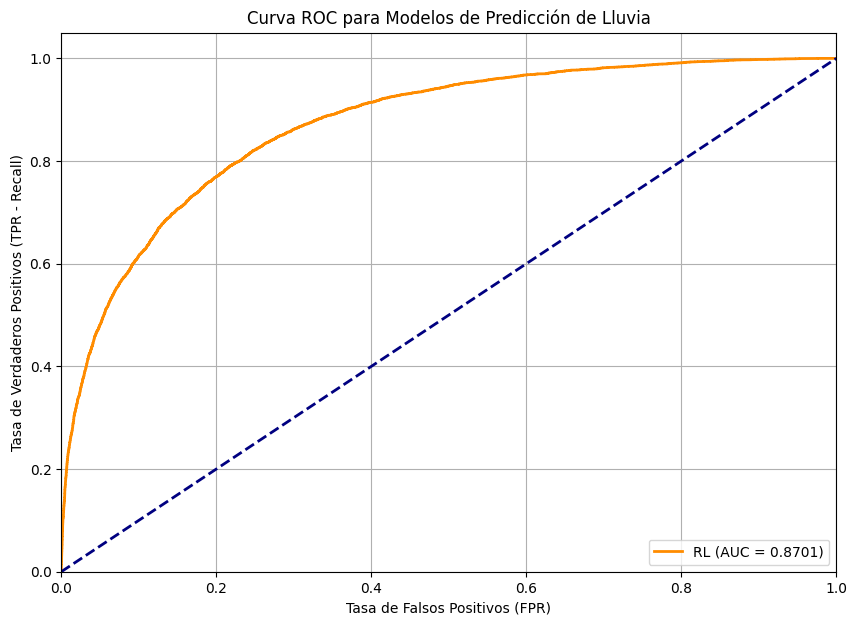

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- 1. Calcular TPR y FPR ---
# Regresión Logística (RL)
# Obtengo las probabilidades de predicción del modelo
y_probs = logistic_model.predict_proba(X_test_prueba)[:, 1]  # Predict probability for the positive class (1)

fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_probs)
roc_auc_log = auc(fpr_log, tpr_log)


# --- 2. Trazar la Curva ---
plt.figure(figsize=(10, 7))
plt.plot(fpr_log, tpr_log, color='darkorange', lw=2,
         label=f'RL (AUC = {roc_auc_log:.4f})')
#plt.plot(fpr_rf, tpr_rf, color='blue', lw=2,
        # label=f'RF (AUC = {roc_auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Línea al azar
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR - Recall)')
plt.title('Curva ROC para Modelos de Predicción de Lluvia')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Comentario: El modelo con la curva más pegada a la esquina superior izquierda es el mejor.

Al analizar la curva ROC se observa que el modelo presenta una muy buena capacidad de discriminación, caracterizada por un alto TPR (True Positive Rate) y un bajo FPR (False Positive Rate).
La curva se ubica por encima de la línea del azar, lo que confirma que el modelo predice significativamente mejor que una clasificación aleatoria.

Además, el AUC obtenido (0.87) indica un elevado poder predictivo, ya que el área bajo la curva se aproxima al valor ideal de 1. Esto significa que el modelo logra distinguir con alta precisión entre los casos positivos y negativos, acercándose al comportamiento de un modelo casi perfecto, con una baja proporción de falsos positivos y falsos negativos.

In [ ]:
from sklearn.metrics import f1_score

# Iterar sobre los umbrales de la RL para maximizar el F1-Score
best_f1 = 0
best_threshold = 0.5

# Usamos los umbrales calculados de la curva ROC para la RL
for i in range(len(thresholds_log)):
    current_threshold = thresholds_log[i]
    y_pred_i = (y_probs >= current_threshold).astype(int)
    f1 = f1_score(y_test, y_pred_i, zero_division=0)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = current_threshold

print(f"\n--- Umbral Óptimo (Máximo F1-Score) ---")
print(f"Umbral: {best_threshold:.4f}")
print(f"F1-Score Máximo: {best_f1:.4f}")


--- Umbral Óptimo (Máximo F1-Score) ---
Umbral: 0.6179
F1-Score Máximo: 0.6371


Según el último bloque de código, podemos observar que el umbral 0.5 no necesariamente representa la mejor opción para nuestro modelo.
Utilizar este valor implicaría que el modelo clasifique aproximadamente la mitad de las observaciones como positivas y la otra mitad como negativas.
Sin embargo, en nuestro dataset las clases no se encuentran perfectamente balanceadas, por lo que mantener ese umbral podría reducir la capacidad predictiva del modelo.

En este caso, el umbral óptimo obtenido fue 0.6179, lo que permite alcanzar un mejor equilibrio entre la sensibilidad (TPR) y la especificidad (1 - FPR), mejorando así el rendimiento general del modelo.